In [53]:
import numpy as np
import pandas as pd
import random
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve, precision_recall_fscore_support
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report as classification_report_multiout
from itertools import product

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P2'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_P2_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_P2_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_P2_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Attica\GR_Attica_WNV_Dataset_P2_2010_2023.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)


dataset1.head()

dataset2.head()

dataset3.head()

dataset4.head()

dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(308, 73)


In [37]:
dataset.head()

,NUTS3_ID,year,x,y,ndvi_p2,ndwi_p2,ndmi_p2,ndbi_p2,lst_mean_p2,lst_day_mean_p2,lst_night_mean_p2,lst_min_p2,lst_max_p2,prec_mean_p2,prec_acc_p2,mosq_mean_p2,mosq_sum_p2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2010,22.217953,40.552111,0.353989,-0.190765,0.140956,-0.140956,8.226205,12.679895,3.772516,-4.091667,4.901481,5.590988,1001.929838,15.765601,2860.092593,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,5025.2,5265.4,49,"[0, 0, 6, 36, 7, 0]"
1,EL522,2010,23.139033,40.693632,0.286727,-0.094388,0.159146,-0.159146,9.062688,13.908152,4.217224,-4.194062,6.827969,4.633141,829.349932,13.710643,2491.554688,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,9804.6,10058.8,81,"[0, 0, 11, 50, 20, 0]"
2,EL523,2010,22.762317,41.016275,0.237641,-0.022679,0.197625,-0.197625,8.509787,13.544245,3.475329,-5.153696,6.112391,4.466064,802.915035,13.273372,2409.163043,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,5916.0,24162.0,9803.0,39881.0,5598.0,23417.0,11860.0,40875.0,1169.86,5809.2,5920.4,23,"[0, 0, 6, 13, 4, 0]"
3,EL524,2010,22.109782,40.888821,0.319691,-0.178787,0.116277,-0.116277,8.099761,12.907913,3.291608,-4.296905,5.501364,5.547225,995.774511,15.403738,2790.295455,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,31,36,30,12,9,4,4,4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,5025.2,5265.4,57,"[0, 0, 3, 41, 13, 0]"
4,EL525,2010,22.442423,40.269959,0.378999,-0.255164,0.109803,-0.109803,9.232783,13.514089,4.951478,-3.229556,6.584222,5.067479,908.264117,18.863691,3417.888889,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,31,36,30,12,12,1,6,7,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,10377.0,39695.0,11841.0,61913.0,10120.0,40015.0,14312.0,64447.0,1815.79,5025.2,5265.4,13,"[0, 0, 1, 7, 5, 0]"


In [38]:
dataset.cases_total.sum()

1724

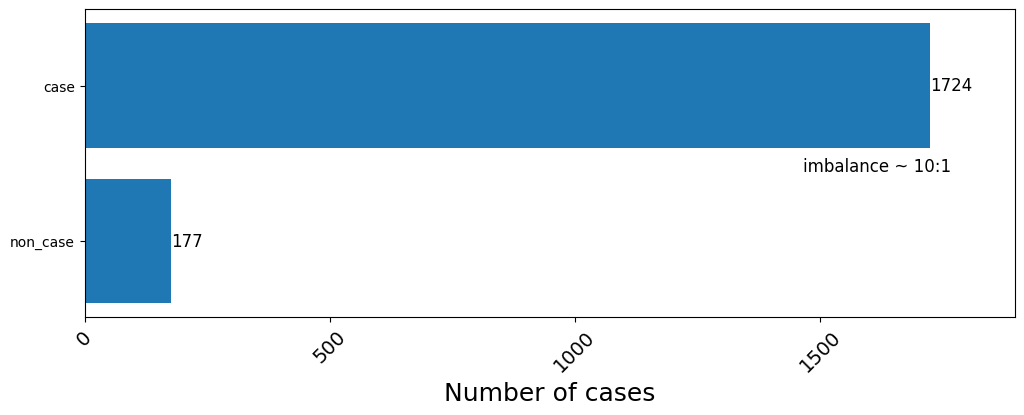

In [39]:
plot_imbalance(dataset, target_column='cases_total')

In [40]:
dsc = dataframe_describe(dataset, target_column = 'cases_total')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,13,260,273,0.05%
1,2011,7,91,98,0.08%
2,2012,10,141,151,0.07%
3,2013,12,83,95,0.14%
4,2014,19,13,32,1.46%
5,2015,22,0,22,inf%
6,2016,22,0,22,inf%
7,2017,22,0,22,inf%
8,2018,4,293,297,0.01%
9,2019,5,221,226,0.02%


In [41]:
X = dataset.drop(columns=['cases_total','cases_arr'])
y = dataset['cases_arr']
s = dataset['cases_total']

In [67]:
n_folds = 5
#k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [68]:
features_to_remove = ['x', 'y', 'year', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5']

feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names)

Index(['ndvi_p2', 'ndwi_p2', 'ndmi_p2', 'ndbi_p2', 'lst_mean_p2',
       'lst_day_mean_p2', 'lst_night_mean_p2', 'lst_min_p2', 'lst_max_p2',
       'prec_mean_p2', 'prec_acc_p2', 'mosq_mean_p2', 'mosq_sum_p2', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lc_type2', 'distance_to_coast', 'distance_to_river',
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km',
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m',
       'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std',
       'aspect_mean_200m_std', 'elevation_mean_1km_std',
       'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',
       'males_lt15', 'males_15t64', 'males_gt65', 'males_total',
       'females_lt15', 'females_15t64', 'females_gt65', 'females_total',
       'mio_eur', 'l_total', 'unl_total'],
      dtype='object')


In [69]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, s):
    print(f'Fold: {fold_counter+1}/{n_folds}')
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: json.loads(x))
    data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: np.array(x))
    data_train = convert_multiple_cases_array_weighted(data_train, target_col='cases_arr')
    # data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: np.where(x == 0, 0, 1))

    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: json.loads(x))
    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: np.array(x))
    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: np.where(x == 0, 0, 1))

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives_train = np.sum(np.vstack(data_train['cases_arr'].to_numpy()) == 0, axis=0)
    sum_positives_train = np.sum(np.vstack(data_train['cases_arr'].to_numpy()) == 1, axis=0)
    scale_train = (sum_negatives_train / sum_positives_train)

    sum_negatives_test = np.sum(np.vstack(data_test['cases_arr'].to_numpy()) == 0, axis=0)
    sum_positives_test = np.sum(np.vstack(data_test['cases_arr'].to_numpy()) == 1, axis=0)
    scale_test = (sum_negatives_test / sum_positives_test)

    params = {
        "seed": 0,
        "objective": "binary:logistic", 
        "eval_metric": "logloss",
        "device": "cuda", 
        "tree_method": "hist",
        "n_estimators": 150,
        "learning_rate": 0.1,           #default 0.3, range[0,1], large values lead to overfitting
        "min_split_loss": 1,          #default 0, range[0,inf], large values lead to underfitting
        "max_depth": 2,                 #default 6, range[0,inf], large values lead to overfitting
        "reg_alpha": 1,                 #default 0, range[0,inf], large values lead to underfitting
        "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
        "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
        "scale_pos_weight": 2, 
        }

    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases_total'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases_total'])

    y_train = data_train['cases_arr']
    y_test = data_test['cases_arr']

    print(f"Training set 0/1 Ratio: {scale_train} Mean: {np.mean(scale_train[~np.isinf(scale_train)]):.2f}")
    print(f"Test set 0/1 Ratio: {scale_test} Mean: {np.mean(scale_test[~np.isinf(scale_test)]):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    y_train_np = np.stack(y_train.to_numpy())
    y_test_np = np.stack(y_test.to_numpy())

    model = xgb.XGBClassifier(**params)   
    model_multiout =  MultiOutputClassifier(model)
    trained_model = model_multiout.fit(X_train_imputed, y_train_np)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_prob_temp = []

    for item in y_train_prob:
        y_train_prob_temp.append(item[:, 1])

    y_test_prob_temp = []

    for item in y_test_prob:
        y_test_prob_temp.append(item[:, 1])

    y_train_prob_stacked = np.hstack(y_train_prob_temp)
    y_test_prob_stacked = np.hstack(y_test_prob_temp)

    y_train_prob_stacked_reshaped = y_train_prob_stacked.reshape(y_train_np.shape)
    y_test_prob_stacked_reshaped = y_test_prob_stacked.reshape(y_test_np.shape)

    y_train_list.append(y_train_np)
    y_test_list.append(y_test_np)
    y_train_prob_list.append(y_train_prob_stacked_reshaped)
    y_test_prob_list.append(y_test_prob_stacked_reshaped)
    fold_counter += 1

Fold: 1/5
Training set 0/1 Ratio: [135.25        26.25         1.32905983   0.45721925   0.74121406
   5.26436782] Mean: 28.22
Test set 0/1 Ratio: [       inf        inf 2.875      1.21428571 1.58333333 5.88888889] Mean: 2.89
Fold: 2/5
Training set 0/1 Ratio: [152.25        29.65         1.70044053   0.34725275   0.60892388
   5.13      ] Mean: 31.61
Test set 0/1 Ratio: [       inf        inf 3.42857143 1.95238095 1.58333333 7.85714286] Mean: 3.71
Fold: 3/5
Training set 0/1 Ratio: [        inf 30.6875      1.88068182  0.48680352  0.70134228  3.56756757] Mean: 7.46
Test set 0/1 Ratio: [61.         61.          3.13333333  1.48        1.81818182 11.4       ] Mean: 23.31
Fold: 4/5
Training set 0/1 Ratio: [142.75        94.83333333   1.25490196   0.39563107   0.53743316
   5.53409091] Mean: 40.88
Test set 0/1 Ratio: [        inf 29.5         5.77777778  1.77272727  2.38888889  5.1       ] Mean: 8.91
Fold: 5/5
Training set 0/1 Ratio: [138.          29.88888889   1.75247525   0.41116751   0.

In [70]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [71]:
train_loss = log_loss_vector(y_train_true, y_train_proba)
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss_vector(y_test_true, y_test_proba)
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 1.2833
Test Loss: 0.9061


In [88]:
classification_thresholds = optimal_threashold_fbeta_vector(y_train_proba, y_train_true, beta = 0.25, round_factor = 2)
print(classification_thresholds)

[0.1  0.99 0.94 0.23 0.55 0.01]


In [89]:
# classification_thresholds_test = optimal_threashold_fbeta_vector(y_test_proba, y_test_true, beta = 4, round_factor = 2)
# print(classification_thresholds_test)

In [90]:
y_train_pred = np.where(y_train_proba < classification_thresholds, 0, 1)
y_test_pred = np.where(y_test_proba < classification_thresholds, 0, 1)

In [91]:
# y_train_pred_with_test = np.where(y_train_proba < classification_thresholds_test, 0, 1)
# y_test_pred_with_test = np.where(y_test_proba < classification_thresholds_test, 0, 1)

In [92]:
hm_loss = hamming_loss(y_test_true, y_test_pred)
print(f"Hamming Loss: {hm_loss}")

Hamming Loss: 0.3852813852813853


In [93]:
beta = 4

print(f"{classification_report_multiout(y_test_true, y_test_pred, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October'])}\n\nWeighted f{beta}-score: {(precision_recall_fscore_support(y_test_true, y_test_pred, beta = beta, average='weighted')[2]):.2f}")

              precision    recall  f1-score   support

         May       0.01      1.00      0.01         1
        June       0.00      0.00      0.00         4
        July       0.17      0.02      0.03        62
      August       0.33      0.33      0.33       114
   September       0.29      0.18      0.22       102
     October       0.14      0.94      0.24        36

   micro avg       0.16      0.29      0.21       319
   macro avg       0.16      0.41      0.14       319
weighted avg       0.26      0.29      0.22       319
 samples avg       0.14      0.13      0.11       319


Weighted f4-score: 0.26


In [94]:
# print(classification_report_multiout(y_test_true, y_test_pred_with_test, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October']))

In [95]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''
labels = [0,1,2,3,4,5]

cm = multilabel_confusion_matrix(y_test_true, y_test_pred, labels=labels)

print(cm)
print('\n')
print(np.sum(cm, axis=0))

[[[158 149]
  [  0   1]]

 [[304   0]
  [  4   0]]

 [[241   5]
  [ 61   1]]

 [[116  78]
  [ 76  38]]

 [[162  44]
  [ 84  18]]

 [[ 63 209]
  [  2  34]]]


[[1044  485]
 [ 227   92]]


In [96]:
# cm = multilabel_confusion_matrix(y_test_true, y_test_pred_with_test, labels=labels)

# print(cm)
# print('\n')
# print(np.sum(cm, axis=0))

In [19]:
##TODO cells for shap values are incomplete